In [17]:
import rpy2.robjects as robjects
import bayesflow as bf
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bayesflow.diagnostics as diag

from sklearn.metrics import r2_score

In [18]:
# load data from Rdata
robjects.r('load("SpainPROV_CerebrovascularDiseases.Rdata")')

Rs = robjects.r('as.matrix(Rs)')

Rs_numpy = np.array(Rs)


In [19]:
# Compute eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(Rs_numpy)

# Compute covariance matrix Q
Q = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T  # Q = V * D * V.T

def process_Q_full(Q, tol=1e-12):
    # Perform eigen decomposition of Q
    eigenvalues, eigenvectors = np.linalg.eigh(Q)
    
    # Print and handle near-zero eigenvalues
    near_zero_mask = (np.abs(eigenvalues) < tol)
    if np.any(near_zero_mask):
        print("Detected near-zero eigenvalues:", eigenvalues[near_zero_mask])
        print("Setting the corresponding scaling factors to 0.")
    
    # Process all eigenvalues: if eigenvalue < tol, set scaling factor to 0, otherwise 1/sqrt(λ)
    scaling = np.where(np.abs(eigenvalues) < tol, 0.0, 1/np.sqrt(eigenvalues))
    
    # Construct transformation matrix L while keeping all 47 eigenvectors
    L = eigenvectors @ np.diag(scaling)
    
    # Check if L @ L.T approximates Q^{-1} (may degrade for non-positive definite cases)
    M = L @ L.T
    eig_M = np.linalg.eigvalsh(M)
    if np.all(eig_M > -tol):  # Consider numerical errors
        print("Output matrix L @ L.T is positive semi-definite.")
    else:
        print("Warning: Output matrix L @ L.T contains significant negative eigenvalues:", eig_M)
    
    return L

# Example: Assuming Q is defined
L = process_Q_full(Q)


Detected near-zero eigenvalues: [-1.6040939e-16]
Setting the corresponding scaling factors to 0.
Output matrix L @ L.T is positive semi-definite.


/var/folders/xh/6yy1qtv504b1yv27rltr5cdc0000gn/T/ipykernel_18032/3056993783.py:18: RuntimeWarning: invalid value encountered in sqrt
  scaling = np.where(np.abs(eigenvalues) < tol, 0.0, 1/np.sqrt(eigenvalues))


In [20]:
mu = np.zeros(47, dtype=np.float32)
n_obs = 1000

def theta_step(batch_shape=1, low=1.0, high=2.0):
    #tau ~ Uniform(low, high)
    tau_val = np.random.uniform(low=low, high=high)
    tau = np.float32(tau_val)

    z = np.random.randn(L.shape[1]).astype(np.float32)
    
    log_risk_samples = mu + (1/np.sqrt(tau)) * (L @ z)
    
    #theta
    theta = np.concatenate([log_risk_samples, [tau]]).astype(np.float32)
    return {"theta": theta}


def forward_step(theta, **kwargs):
    #theta (48,)
    log_risk = theta[:47]
    # tau = theta[-1] 
    lam = np.exp(log_risk)

    # (n_obs, 47)
    obs = np.random.poisson(lam=lam, size=(n_obs, 47)).astype(np.float32)
    
    return {"x": obs}



In [21]:
simulator = bf.make_simulator(
    [theta_step, forward_step],
    expand_outputs=False
)

def flatten_inference_conditions(data, **kwargs):
    # data:'inference_variables' , 'inference_conditions'
    if "inference_conditions" in data:
        conditions = data["inference_conditions"]
        # inference_conditions (batch_size, 100, 47) -> (batch_size, 4700)
        data["inference_conditions"] = conditions.reshape(conditions.shape[0], -1)
    return data

adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")  #float32
    .rename("theta", "inference_variables")
    .rename("x", "inference_conditions")
    .append(flatten_inference_conditions)  # flatten_inference_conditions
)

In [22]:
num_training_batches   = 500
num_batch_size            = 1024
num_epochs                = 40

In [23]:
affine_flow = bf.networks.CouplingFlow(subnet="mlp")

affine_flow_workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=affine_flow,
)

In [24]:
history = affine_flow_workflow.fit_online(
    epochs=num_epochs,
    number_batches=num_training_batches,
    batch_size=num_batch_size,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - loss: 77.1846 - loss/inference_loss: 77.1846
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - loss: 7.4077 - loss/inference_loss: 7.4077
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - loss: -1.5366 - loss/inference_loss: -1.5366
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - loss: -7.9670 - loss/inference_loss: -7.9670
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - loss: -13.5670 - loss/inference_loss: -13.5670
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - loss: -17.2941 - loss/inference_loss: -17.2941
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - loss: -21.4857 - loss/inference_loss: -21.4857
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - loss: -23.3985 - loss/inference_loss: -23.3985
Epoch 9/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - loss: -25.8171 - loss/inference_loss: -25.8171
Epoch 10/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 2180s 22s/step - loss: -27.9002 - loss/inference_lo

In [ ]:
test_size = 1
test_batch = simulator.sample((test_size,))

theta_true = test_batch["theta"]  # [test_size, 48]
x_test = test_batch["x"]  # [test_size, 4700]

# Perform inference
num_samples = 300

In [26]:
posterior_samples_affine= affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test},  
    num_samples=num_samples
)["theta"]

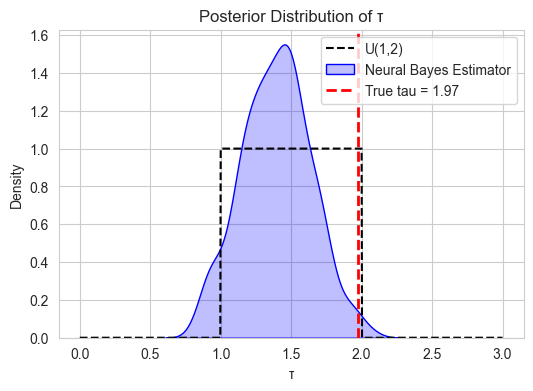

In [27]:
x = np.linspace(0, 3, 1000)  # Set x-axis range
y = stats.uniform.pdf(x, loc=1, scale=1)  # Compute PDF of U(1, 2)

tau_samples = posterior_samples_affine[0, :, -1]  # Shape: (300,)
tau_true = theta_true[0, -1]  # Scalar

plt.figure(figsize=(6, 4))

# Plot the U(1, 2) distribution
plt.plot(x, y, label="U(1,2)", color="black", linestyle="--")

# Plot the KDE of posterior samples
sns.kdeplot(tau_samples, label="Neural Bayes Estimator", fill=True, color="blue")

# Mark the true value of tau
plt.axvline(tau_true, color='red', linestyle='--', linewidth=2,
            label=f"True tau = {tau_true:.2f}")

plt.title("Posterior Distribution of τ")
plt.xlabel("τ")
plt.ylabel("Density")
plt.legend()
plt.show()


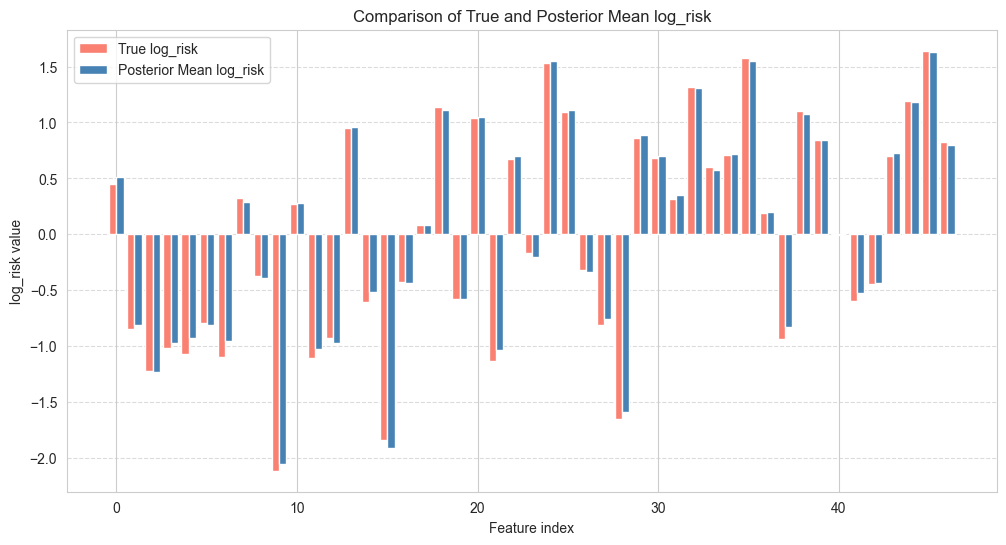

In [28]:
log_risk_samples = posterior_samples_affine[0, :, :47]  # shape: (300, 47)
log_risk_mean = np.mean(log_risk_samples, axis=0)  # shape: (47,)
log_risk_true = theta_true[0, :47]                 # shape: (47,)

x = np.arange(47)

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, log_risk_true, width=0.4, label="True log_risk", color="salmon")
plt.bar(x + 0.2, log_risk_mean, width=0.4, label="Posterior Mean log_risk", color="steelblue")
plt.xlabel("Feature index")
plt.ylabel("log_risk value")
plt.title("Comparison of True and Posterior Mean log_risk")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


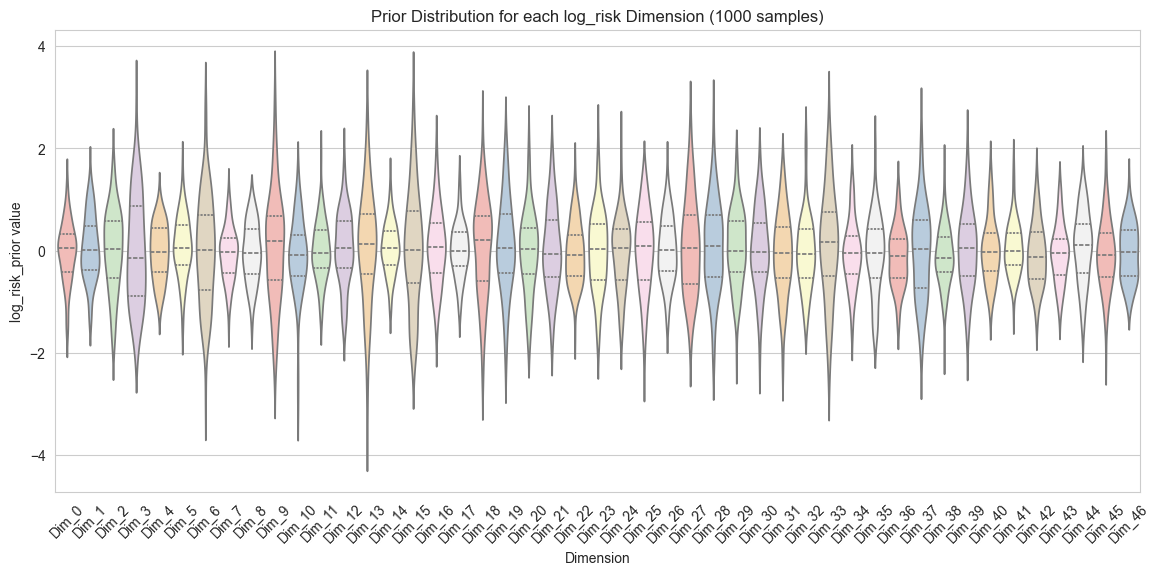

In [29]:
tau = tau_true

z = np.random.randn(L.shape[1]).astype(np.float32)

num_samples = 100
log_risk_prior_samples = []

for _ in range(num_samples):
    z = np.random.randn(L.shape[1]).astype(np.float32)
    log_risk_prior = mu + (1 / np.sqrt(tau_true)) * (L @ z)
    log_risk_prior_samples.append(log_risk_prior)

# DataFrame
data = pd.DataFrame(log_risk_prior_samples, columns=[f"Dim_{i}" for i in range(47)])

# violin plot
plt.figure(figsize=(14, 6))
sns.violinplot(data=data, inner="quartile", palette="Pastel1")
plt.xticks(rotation=45)
plt.xlabel("Dimension")
plt.ylabel("log_risk_prior value")
plt.title("Prior Distribution for each log_risk Dimension (1000 samples)")
plt.show()




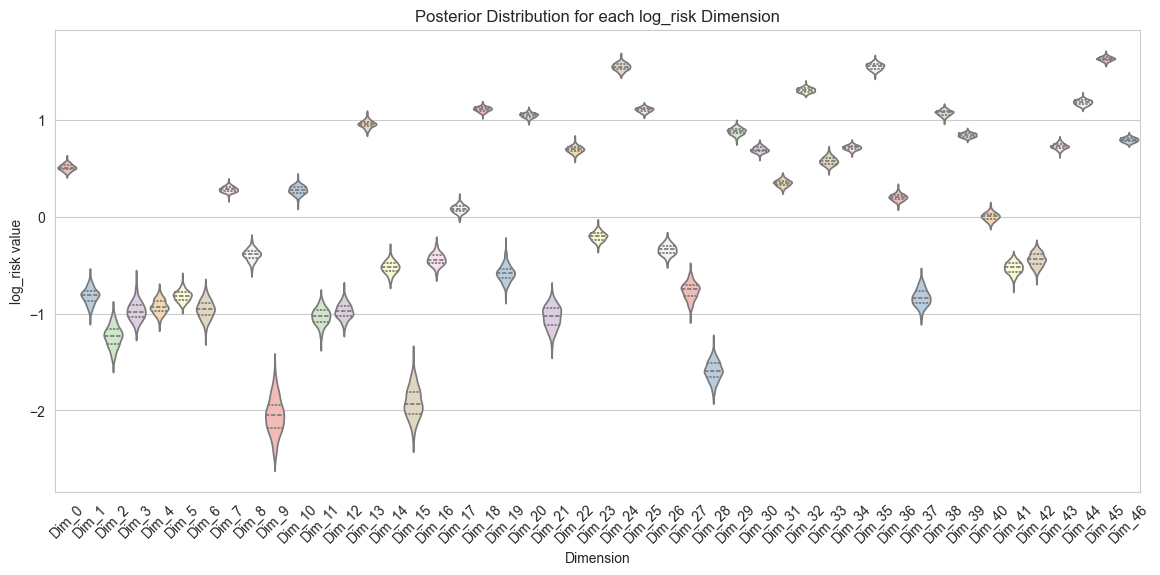

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# DataFrame，47
data = pd.DataFrame(log_risk_samples, columns=[f"Dim_{i}" for i in range(47)])

plt.figure(figsize=(14, 6))
sns.violinplot(data=data, inner="quartile", palette="Pastel1")
plt.xticks(rotation=45)
plt.xlabel("Dimension")
plt.ylabel("log_risk value")
plt.title("Posterior Distribution for each log_risk Dimension")
plt.show()


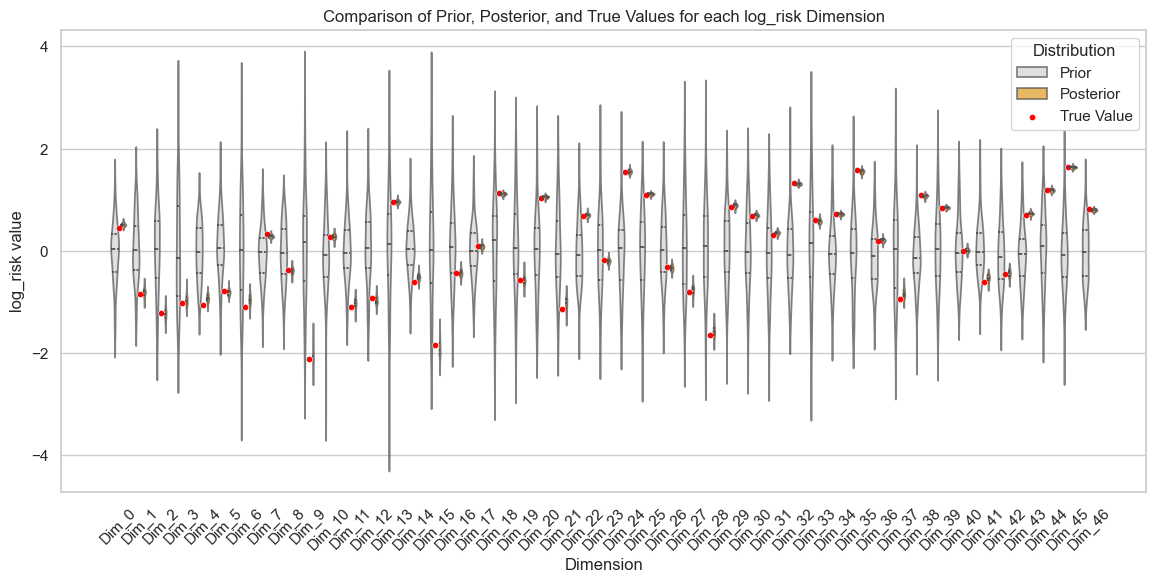

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# get prior and posterior
prior_data = pd.DataFrame(log_risk_prior_samples, columns=[f"Dim_{i}" for i in range(47)])
posterior_data = pd.DataFrame(log_risk_samples, columns=[f"Dim_{i}" for i in range(47)])

# prior and posterior
prior_data['Type'] = 'Prior'
posterior_data['Type'] = 'Posterior'

combined_data = pd.concat([prior_data, posterior_data], ignore_index=True)

combined_data_melted = combined_data.melt(id_vars='Type', var_name='Dimension', value_name='Value')

# plot
plt.figure(figsize=(14, 6))
sns.violinplot(data=combined_data_melted, x='Dimension', y='Value', hue='Type', 
               palette={'Prior': 'lightgrey', 'Posterior': 'orange'}, 
               inner='quartile', alpha=0.7)

# add true value
log_risk_true_df = pd.DataFrame({'Dimension': [f"Dim_{i}" for i in range(47)], 'Value': log_risk_true})
sns.scatterplot(data=log_risk_true_df, x='Dimension', y='Value', color='red', marker='o', s=20, label='True Value')

plt.xticks(rotation=45)
plt.xlabel("Dimension")
plt.ylabel("log_risk value")
plt.title("Comparison of Prior, Posterior, and True Values for each log_risk Dimension")
plt.legend(title='Distribution')
plt.show()


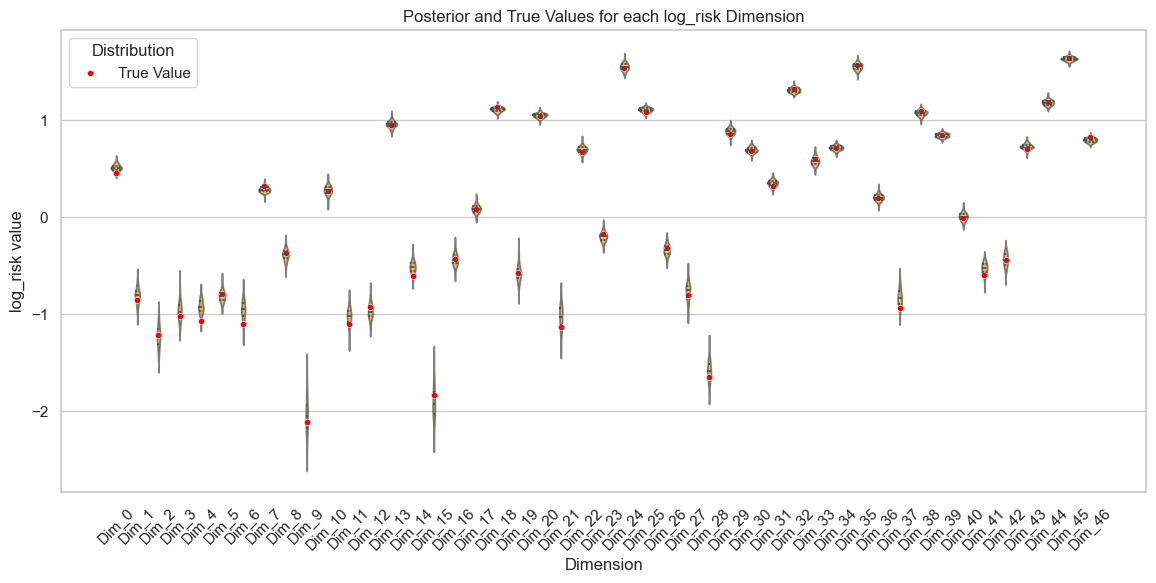

In [ ]:

posterior_data = pd.DataFrame(log_risk_samples, columns=[f"Dim_{i}" for i in range(47)])
posterior_data['Type'] = 'Posterior'

# Melt the DataFrame
combined_data_melted = posterior_data.melt(id_vars='Type', var_name='Dimension', value_name='Value')

# Plot
plt.figure(figsize=(14, 6))
sns.violinplot(data=combined_data_melted, x='Dimension', y='Value', color='orange', 
               inner='quartile', alpha=0.7)

# Add true value
log_risk_true_df = pd.DataFrame({'Dimension': [f"Dim_{i}" for i in range(47)], 'Value': log_risk_true})
sns.scatterplot(data=log_risk_true_df, x='Dimension', y='Value', color='red', marker='o', s=20, label='True Value')

plt.xticks(rotation=45)
plt.xlabel("Dimension")
plt.ylabel("log_risk value")
plt.title("Posterior and True Values for each log_risk Dimension")
plt.legend(title='Distribution')
plt.show()


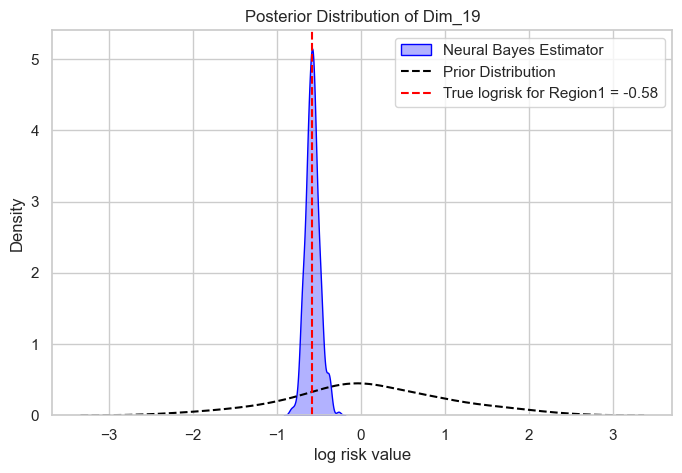

In [32]:
# Extract data for the first dimension
dim_0_prior = prior_data["Dim_19"]
dim_0_posterior = posterior_data["Dim_19"]

# Compute prior range (assuming uniform distribution)
prior_min, prior_max = dim_0_prior.min(), dim_0_prior.max()

# Compute posterior density estimation
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot posterior density estimation
sns.kdeplot(dim_0_posterior, color="blue", fill=True, alpha=0.3, label="Neural Bayes Estimator")

# Plot prior distribution density estimation
sns.kdeplot(dim_0_prior, color="black", linestyle='--', label="Prior Distribution")

# Get the true tau value
true_tau = log_risk_true_df.loc[log_risk_true_df["Dimension"] == "Dim_19", "Value"].values[0]

# Plot true tau vertical line
plt.axvline(true_tau, color="red", linestyle="dashed", label=f"True logrisk for Region1 = {true_tau:.2f}")

# Add title and labels
plt.title("Posterior Distribution of Dim_19")
plt.xlabel("log risk value")
plt.ylabel("Density")
plt.legend()
plt.show()


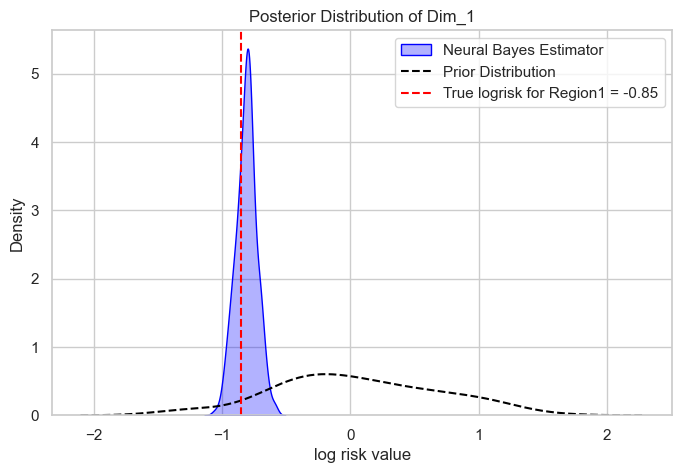

In [33]:
# Extract data for the first dimension
dim_0_prior = prior_data["Dim_1"]
dim_0_posterior = posterior_data["Dim_1"]

# Compute prior range (assuming uniform distribution)
prior_min, prior_max = dim_0_prior.min(), dim_0_prior.max()

# Compute posterior density estimation
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot posterior density estimation
sns.kdeplot(dim_0_posterior, color="blue", fill=True, alpha=0.3, label="Neural Bayes Estimator")

# Plot prior distribution density estimation
sns.kdeplot(dim_0_prior, color="black", linestyle='--', label="Prior Distribution")

# Get the true tau value
true_tau = log_risk_true_df.loc[log_risk_true_df["Dimension"] == "Dim_1", "Value"].values[0]

# Plot true tau vertical line
plt.axvline(true_tau, color="red", linestyle="dashed", label=f"True logrisk for Region1 = {true_tau:.2f}")

# Add title and labels
plt.title("Posterior Distribution of Dim_1")
plt.xlabel("log risk value")
plt.ylabel("Density")
plt.legend()
plt.show()


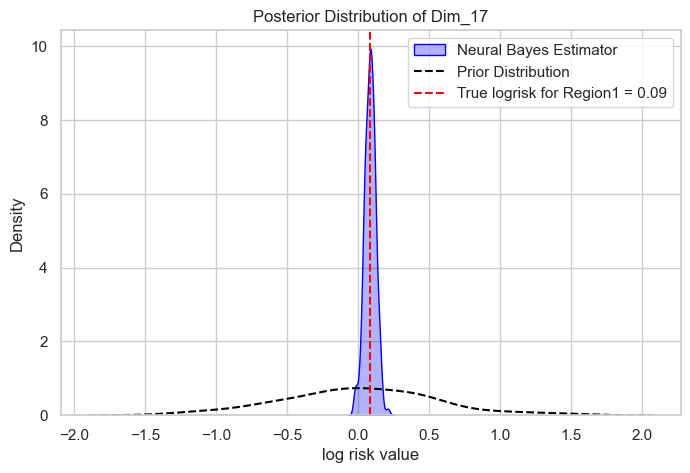

In [34]:
# Extract data for the first dimension
dim_0_prior = prior_data["Dim_17"]
dim_0_posterior = posterior_data["Dim_17"]

# Compute prior range (assuming uniform distribution)
prior_min, prior_max = dim_0_prior.min(), dim_0_prior.max()

# Compute posterior density estimation
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot posterior density estimation
sns.kdeplot(dim_0_posterior, color="blue", fill=True, alpha=0.3, label="Neural Bayes Estimator")

# Plot prior distribution density estimation
sns.kdeplot(dim_0_prior, color="black", linestyle='--', label="Prior Distribution")

# Get the true tau value
true_tau = log_risk_true_df.loc[log_risk_true_df["Dimension"] == "Dim_17", "Value"].values[0]

# Plot true tau vertical line
plt.axvline(true_tau, color="red", linestyle="dashed", label=f"True logrisk for Region1 = {true_tau:.2f}")

# Add title and labels
plt.title("Posterior Distribution of Dim_17")
plt.xlabel("log risk value")
plt.ylabel("Density")
plt.legend()
plt.show()


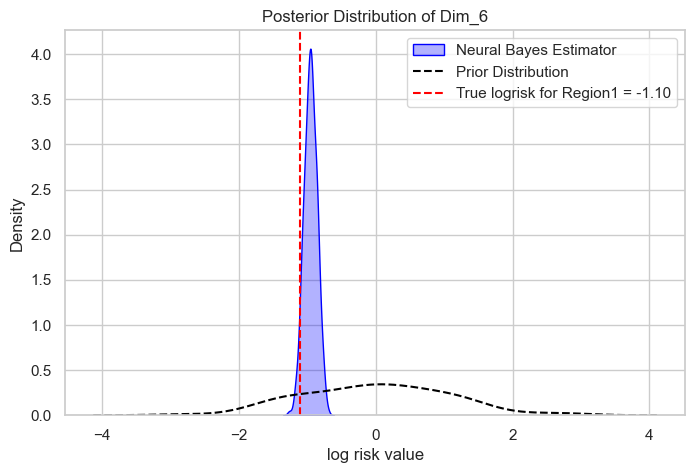

In [35]:
# Extract data for the first dimension
dim_0_prior = prior_data["Dim_6"]
dim_0_posterior = posterior_data["Dim_6"]

# Compute prior range (assuming uniform distribution)
prior_min, prior_max = dim_0_prior.min(), dim_0_prior.max()

# Compute posterior density estimation
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot posterior density estimation
sns.kdeplot(dim_0_posterior, color="blue", fill=True, alpha=0.3, label="Neural Bayes Estimator")

# Plot prior distribution density estimation
sns.kdeplot(dim_0_prior, color="black", linestyle='--', label="Prior Distribution")

# Get the true tau value
true_tau = log_risk_true_df.loc[log_risk_true_df["Dimension"] == "Dim_6", "Value"].values[0]

# Plot true tau vertical line
plt.axvline(true_tau, color="red", linestyle="dashed", label=f"True logrisk for Region1 = {true_tau:.2f}")

# Add title and labels
plt.title("Posterior Distribution of Dim_6")
plt.xlabel("log risk value")
plt.ylabel("Density")
plt.legend()
plt.show()


In [36]:
test_size = 100
test_batch_100 = simulator.sample((test_size,))

theta_true_100 = test_batch_100["theta"]  # [test_size, 48]
x_test_100 = test_batch_100["x"]  # [test_size, 4700]

In [37]:
posterior_samples_affine= affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test_100},  #inference_conditions
    num_samples=300
)["theta"]

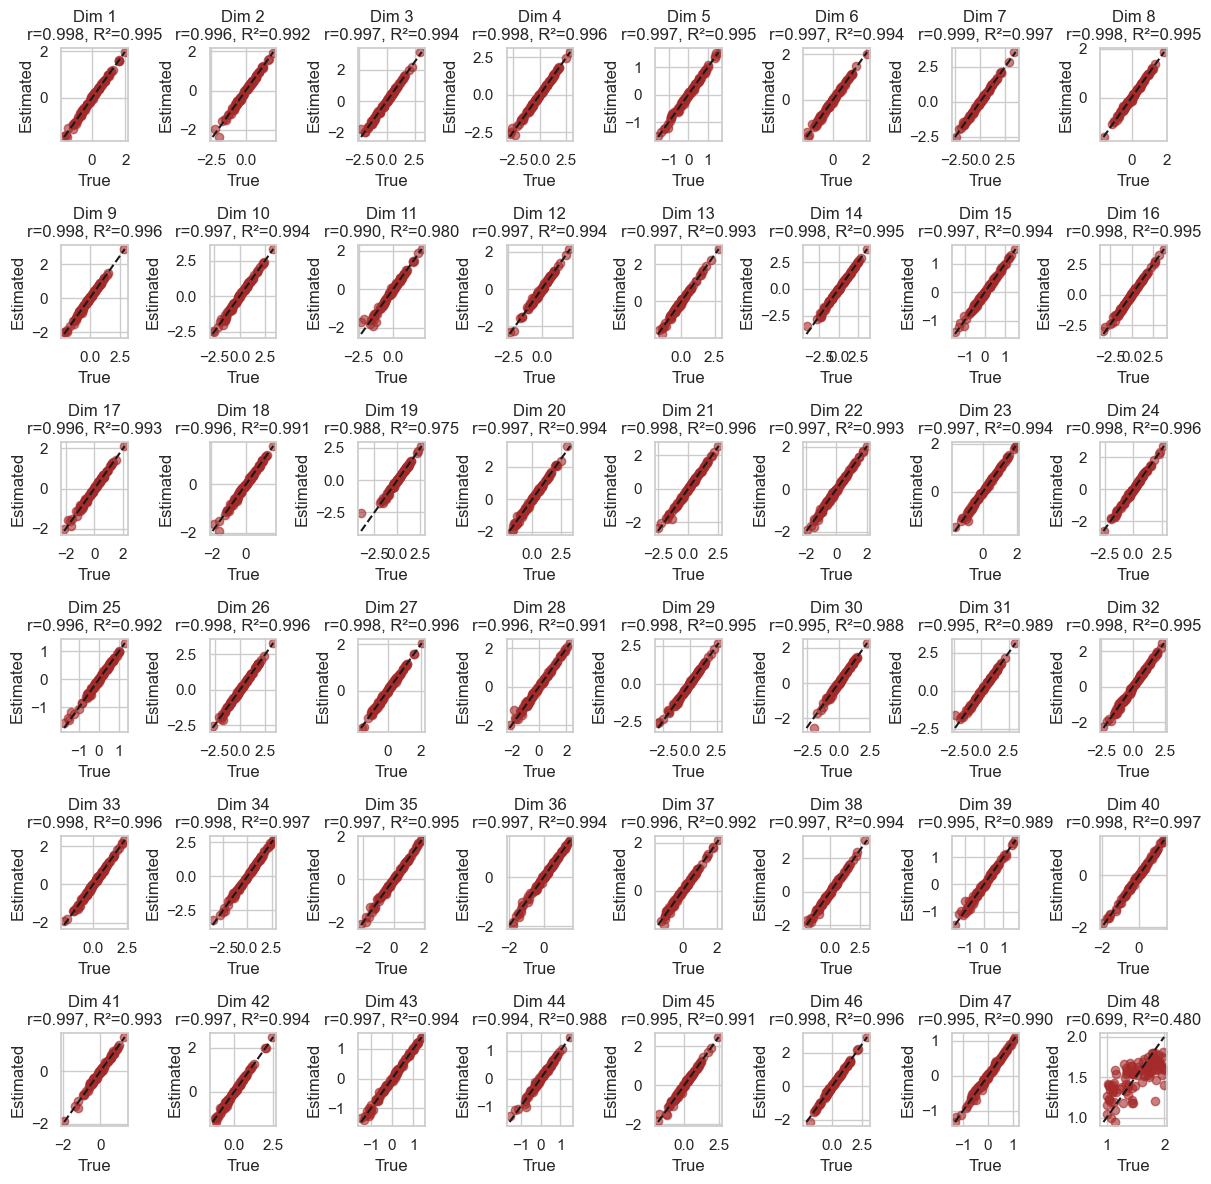

In [38]:
test_size = theta_true_100.shape[0]
n_dim = theta_true_100.shape[1]

# Compute posterior means => shape (test_size, 48)
posterior_means = posterior_samples_affine.mean(axis=1)

# Plot the first 48 dimensions (adjust rows and columns if needed)
n_plot_dims = 48

fig, axes = plt.subplots(6, 8, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_plot_dims):
    ax = axes[i]
    # x-axis: True values, y-axis: Posterior means
    ax.scatter(theta_true_100[:, i], posterior_means[:, i], alpha=0.6, color="brown")
    
    # Plot diagonal line
    min_val = min(theta_true_100[:, i].min(), posterior_means[:, i].min())
    max_val = max(theta_true_100[:, i].max(), posterior_means[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], "k--")

    # Compute correlation coefficient & R²
    r = np.corrcoef(theta_true_100[:, i], posterior_means[:, i])[0, 1]
    r2 = r2_score(theta_true_100[:, i], posterior_means[:, i])
    
    ax.set_title(f"Dim {i+1}\nr={r:.3f}, R²={r2:.3f}")
    ax.set_xlabel("True")
    ax.set_ylabel("Estimated")

plt.tight_layout()
plt.show()


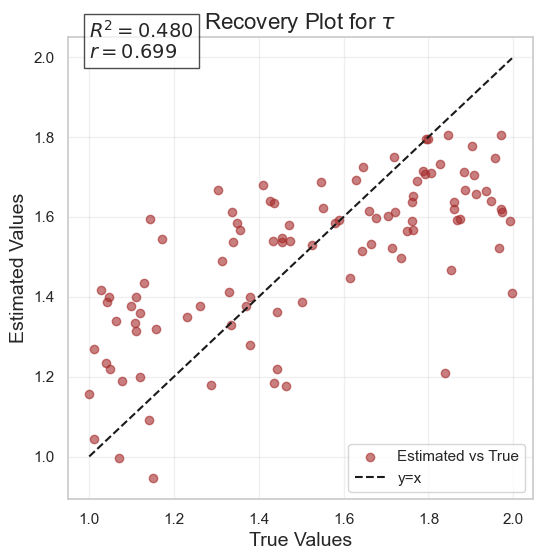

In [39]:
dim_index = 47 

true_values = theta_true_100[:, dim_index]  # shape: (test_size,)
estimated_values = posterior_means[:, dim_index]  # shape: (test_size,)

# get r and r^2
r = np.corrcoef(true_values, estimated_values)[0, 1]
r2 = r2_score(true_values, estimated_values)

# plot 
plt.figure(figsize=(6, 6))
plt.scatter(true_values, estimated_values, alpha=0.6, color="brown", label="Estimated vs True")
plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], "k--", label="y=x") 

plt.text(true_values.min(), true_values.max(), rf"$R^2 = {r2:.3f}$" + "\n" + rf"$r = {r:.3f}$",
         fontsize=14, bbox=dict(facecolor="white", edgecolor="black", alpha=0.7))

plt.xlabel("True Values", fontsize=14)
plt.ylabel("Estimated Values", fontsize=14)
plt.title(r"Recovery Plot for $\tau$", fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


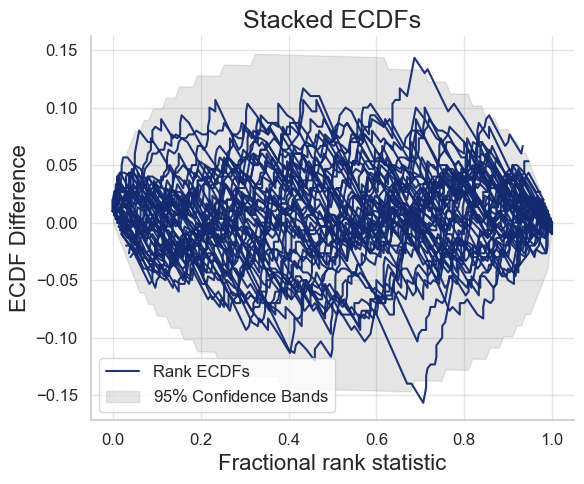

In [40]:
f = diag.calibration_ecdf(
    targets=posterior_samples_affine,   # Posterior samples, shape (N=100, S=300, D=48)
    references=theta_true_100,          # True parameters, shape (N=100, D=48)
    stacked=True,
    difference=True,
    legend_fontsize=12,
    figsize=(6, 5)                      # Note: Parameter name is figsize
)


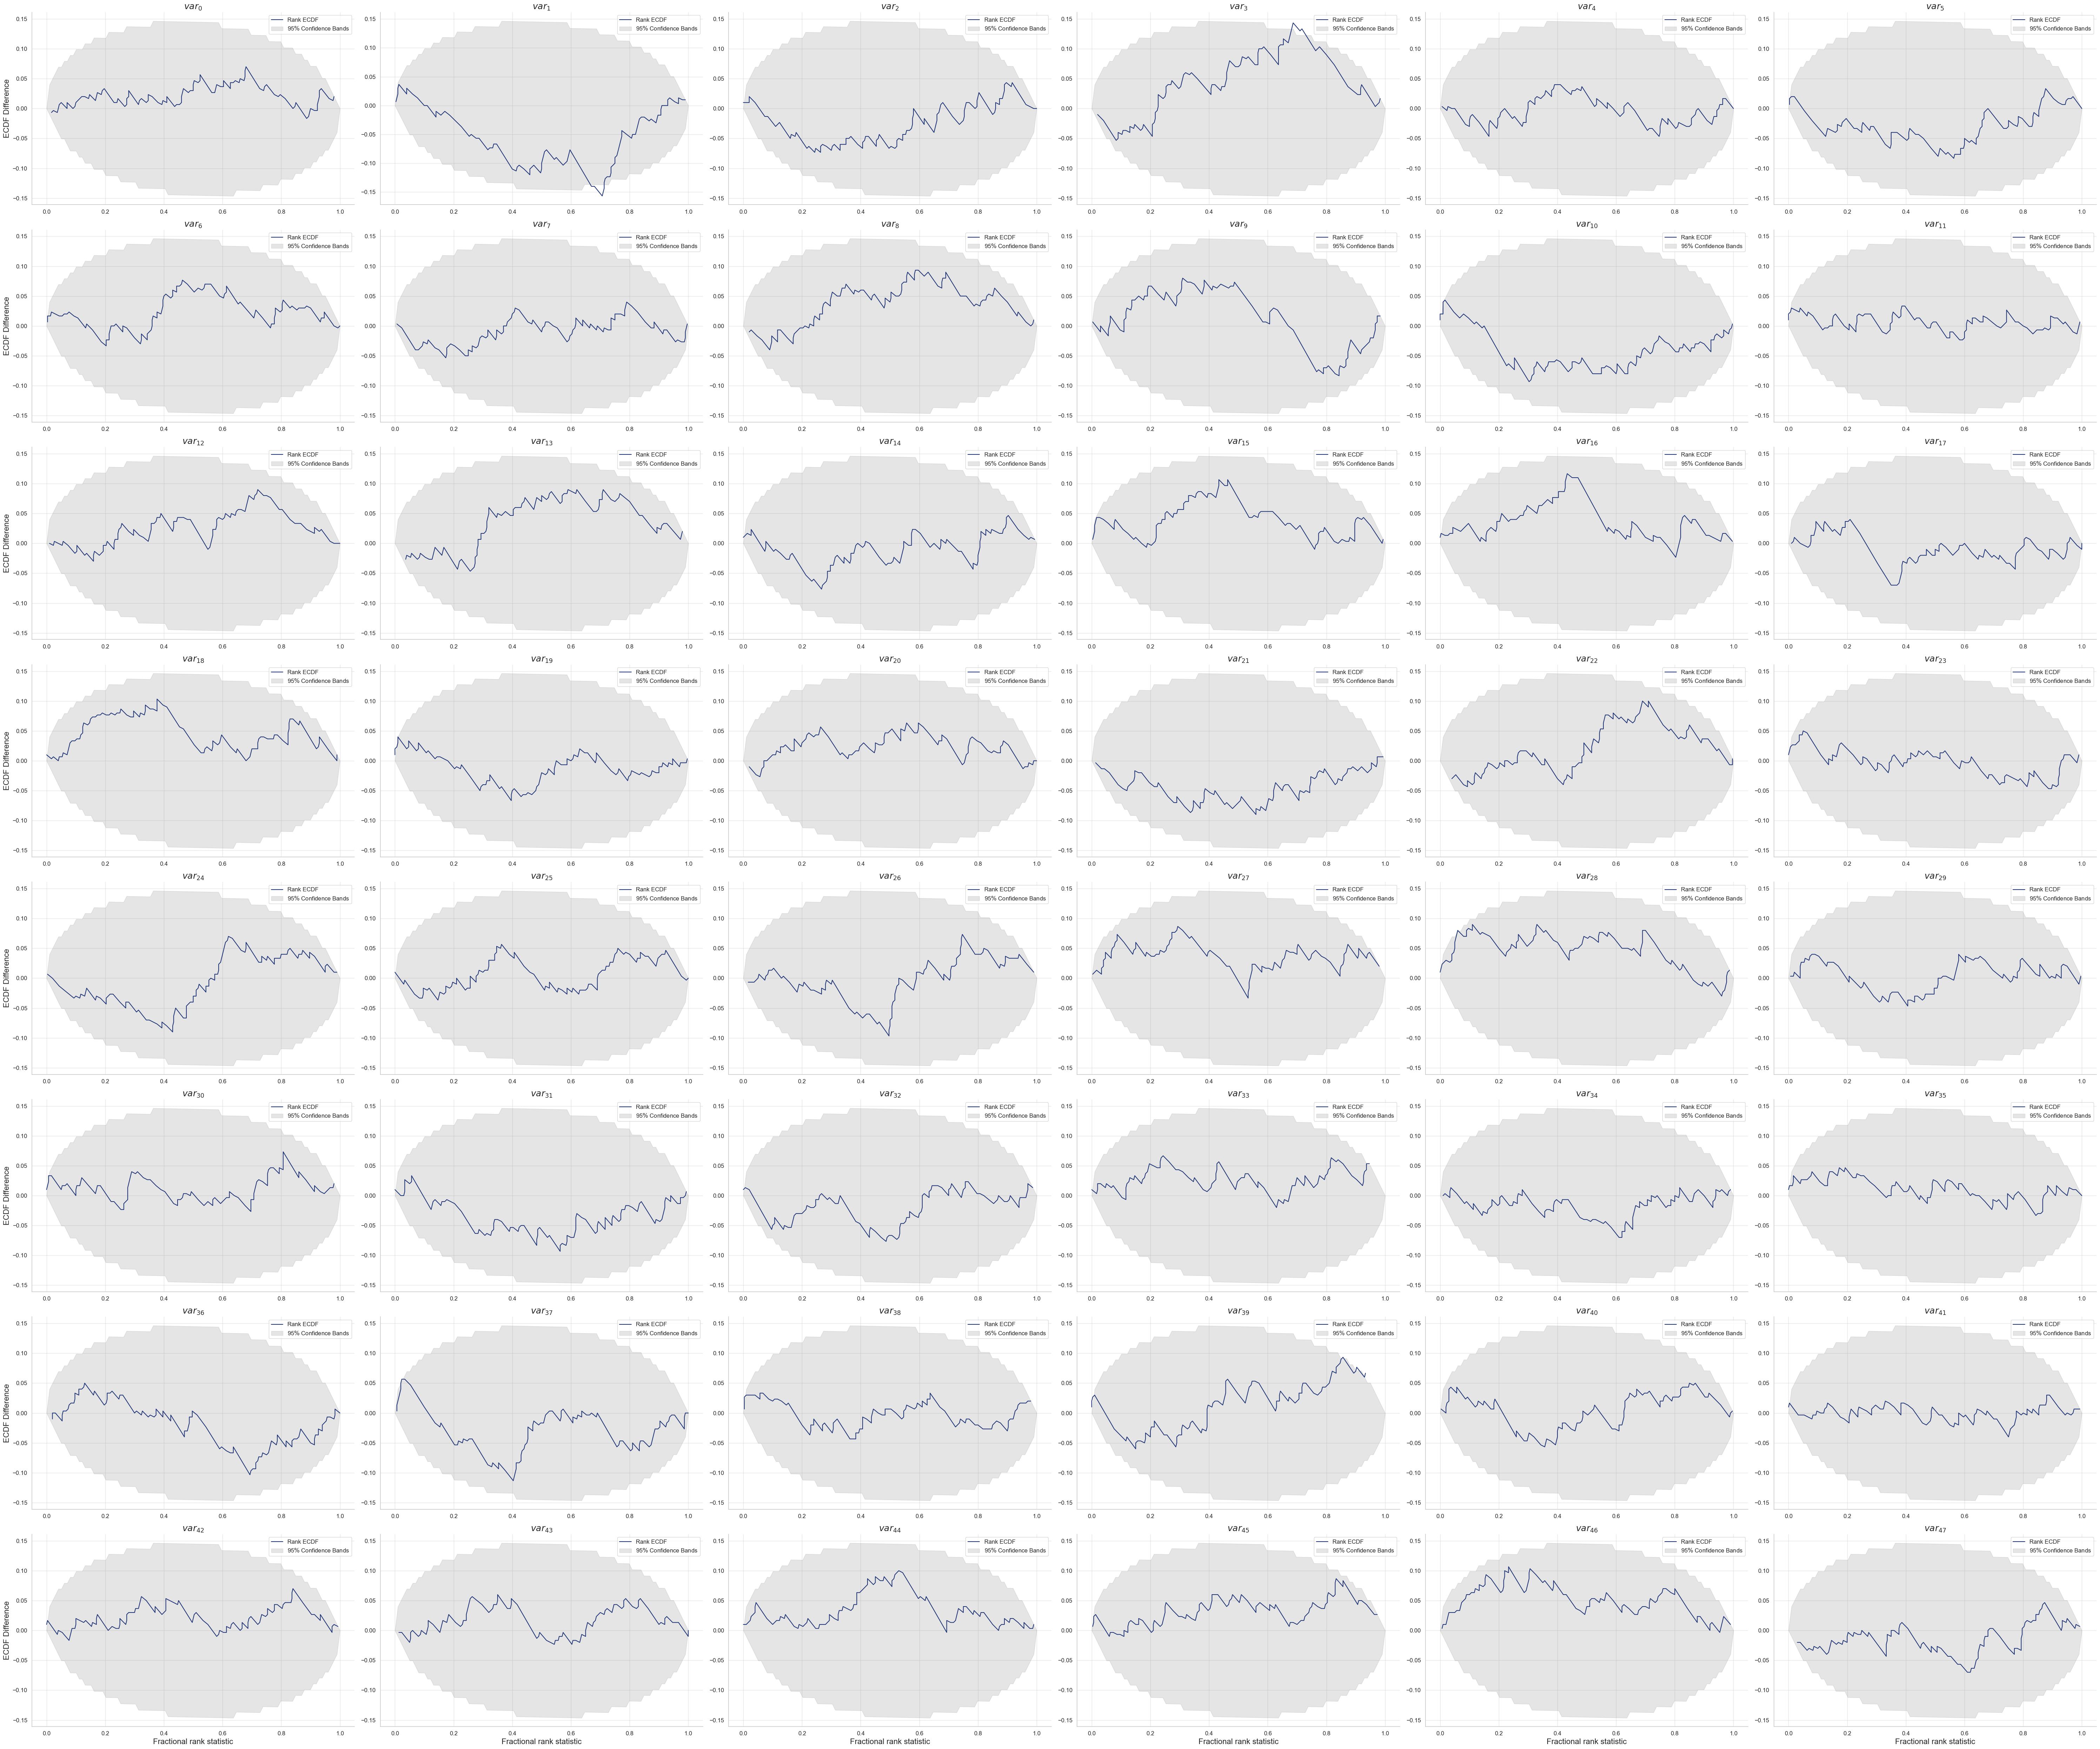

In [41]:
f = diag.calibration_ecdf(
    targets=posterior_samples_affine,   # Posterior samples, shape (N=100, S=300, D=48)
    references=theta_true_100,          # True parameters, shape (N=100, D=48)
    stacked=False,
    difference=True,
    legend_fontsize=12,
    figsize=(60, 50)                    
)


In [42]:
posterior_samples_affine.shape #(100, 300, 48)

(100, 300, 48)

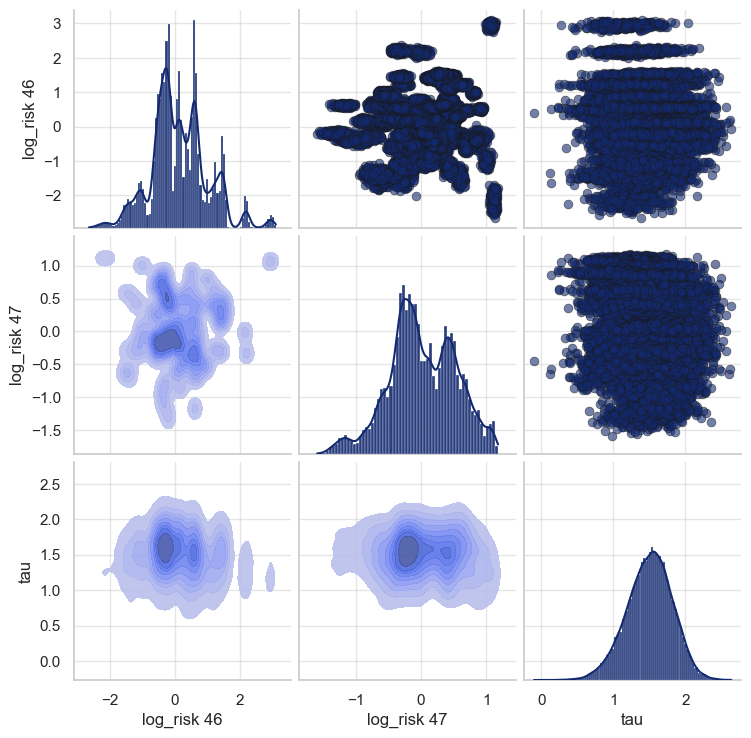

In [43]:

# Reshape to (test_size * n_samples, 48)
flattened_samples = posterior_samples_affine.reshape(-1, posterior_samples_affine.shape[-1])

# Extract the last 3 parameters (dimensions)
subset = {
    "log_risk 46": flattened_samples[:, -3],
    "log_risk 47": flattened_samples[:, -2],
    "tau":   flattened_samples[:, -1]
}

# Generate Pair Plot using pairs_samples
grid = diag.plots.pairs_samples(subset)

plt.show()


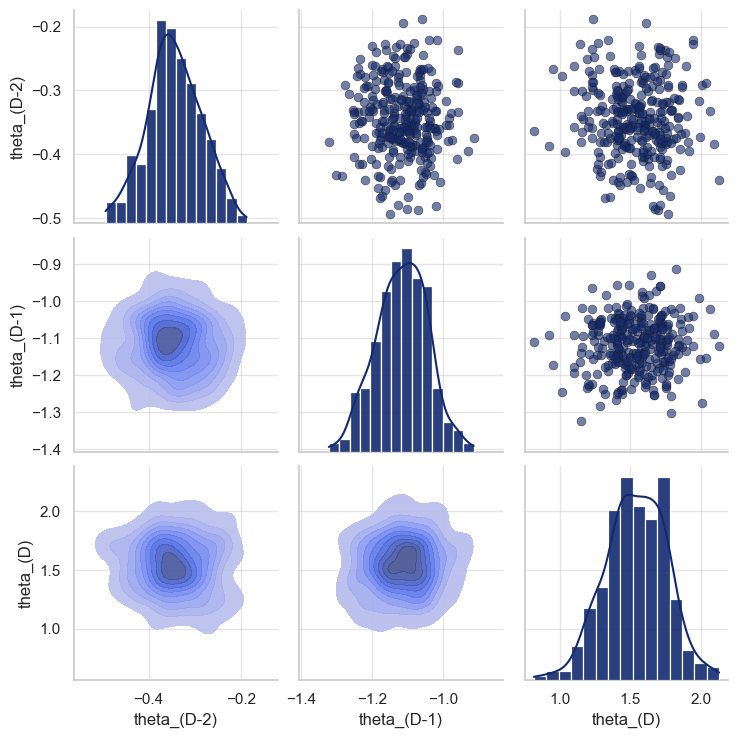

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import bayesflow.diagnostics as diag

posterior_first = posterior_samples_affine[0]  

# Extract the last 3 parameters (dimensions)
subset = {
    "theta_(D-2)": posterior_first[:, -3],
    "theta_(D-1)": posterior_first[:, -2],
    "theta_(D)":   posterior_first[:, -1]
}

# Generate Pair Plot using pairs_samples
grid = diag.plots.pairs_samples(subset)

plt.show()
